<a href="https://colab.research.google.com/github/kevinvandewalker-eng/prismogenesis-whale-hunt/blob/main/Gnomon_shell_pulse_phase_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

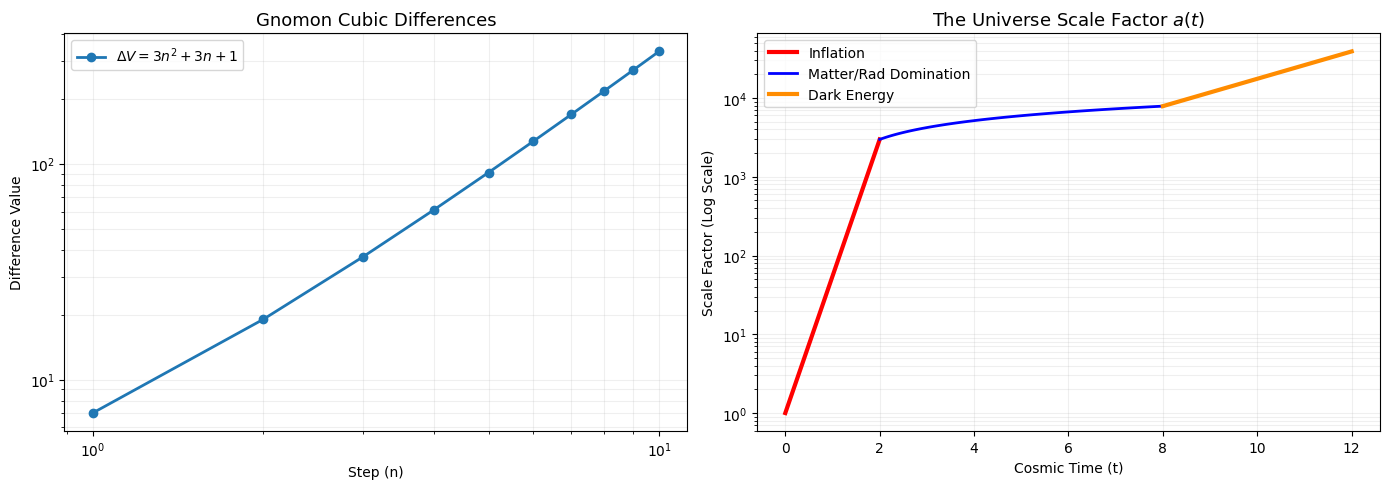

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Gnomon logic: (n+1)^3 - n^3
n = np.arange(1, 11)
gnomon_diffs = 3*n**2 + 3*n + 1

# 2. Cosmic Evolution Model (Simplified for visualization)
# Phase A: Inflation (Exponentially fast)
t_inflation = np.linspace(0, 2, 100)
a_inflation = np.exp(4 * t_inflation)

# Phase B: Matter/Radiation Dominated (Decelerating power law)
t_mid = np.linspace(2, 8, 100)
a_mid = a_inflation[-1] * (t_mid - t_inflation[-1] + 1)**(0.5)

# Phase C: Dark Energy (Accelerating exponential)
t_dark_energy = np.linspace(8, 12, 100)
a_dark_energy = a_mid[-1] * np.exp(0.4 * (t_dark_energy - t_mid[-1]))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Gnomon (Polynomial growth)
ax[0].loglog(n, gnomon_diffs, 'o-', linewidth=2, markersize=6, label=r'$\Delta V = 3n^2 + 3n + 1$')
ax[0].set_title('Gnomon Cubic Differences', fontsize=13)
ax[0].set_xlabel('Step (n)')
ax[0].set_ylabel('Difference Value')
ax[0].grid(True, which="both", ls="-", alpha=0.2)
ax[0].legend()

# Plot 2: Full Cosmic Scale Factor Evolution
ax[1].semilogy(t_inflation, a_inflation, color='red', label='Inflation', linewidth=3)
ax[1].semilogy(t_mid, a_mid, color='blue', label='Matter/Rad Domination', linewidth=2)
ax[1].semilogy(t_dark_energy, a_dark_energy, color='darkorange', label='Dark Energy', linewidth=3)

ax[1].set_title('The Universe Scale Factor $a(t)$', fontsize=13)
ax[1].set_xlabel('Cosmic Time (t)')
ax[1].set_ylabel('Scale Factor (Log Scale)')
ax[1].grid(True, which="both", ls="-", alpha=0.2)
ax[1].legend()

plt.tight_layout()
plt.show()

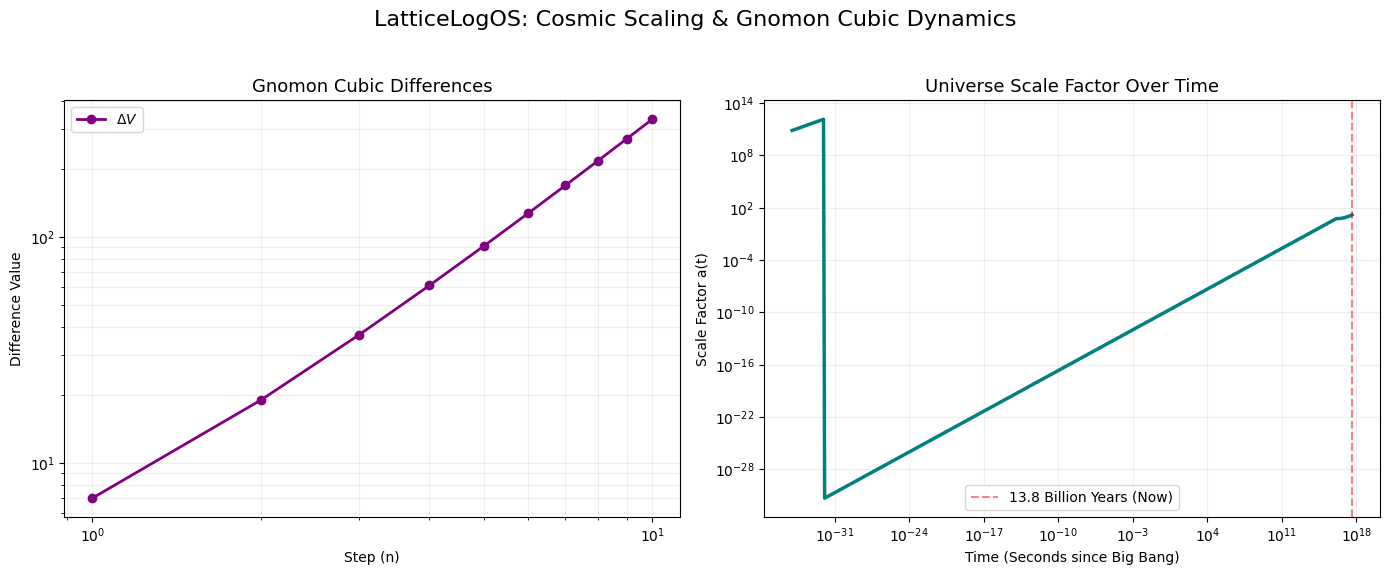

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Gnomon logic: (n+1)^3 - n^3
n = np.arange(1, 11)
gnomon_diffs = 3*n**2 + 3*n + 1

# 2. Cosmic Evolution Model with Realistic Time (Log Scale)
# We use log10 of time in seconds to bridge the gap from 10^-35 to 10^17 (13.8 Gyr)
t_log = np.linspace(-35, 17.6, 500)
time_seconds = 10**t_log

# Approximation of the scale factor a(t)
# Inflation: exponential
# Radiation/Matter: t^1/2 or t^2/3 (power law)
# Dark Energy: exponential
a_t = np.zeros_like(t_log)

for i, log_t in enumerate(t_log):
    if log_t < -32: # Inflation era
        a_t[i] = np.exp(log_t + 60)
    elif log_t < 16.2: # Radiation and Matter era (until ~5-6 Gyr ago)
        a_t[i] = (time_seconds[i])**(2/3) * 10**-10
    else: # Dark Energy era (Modern acceleration)
        a_t[i] = a_t[i-1] * np.exp(0.1 * (log_t - 16.2))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('LatticeLogOS: Cosmic Scaling & Gnomon Cubic Dynamics', fontsize=16)

# Plot 1: Gnomon (The mathematical engine)
ax[0].loglog(n, gnomon_diffs, 'o-', linewidth=2, markersize=6, color='purple', label=r'$\Delta V$')
ax[0].set_title('Gnomon Cubic Differences', fontsize=13)
ax[0].set_xlabel('Step (n)')
ax[0].set_ylabel('Difference Value')
ax[0].grid(True, which="both", ls="-", alpha=0.2)
ax[0].legend()

# Plot 2: Physical Timeline (Log-Log to see the full scope)
# 13.8 Billion Years ~ 4.35e17 seconds
ax[1].loglog(time_seconds, a_t, linewidth=2.5, color='teal')

# Highlight the "Present Day"
present_day_sec = 4.35e17
ax[1].axvline(present_day_sec, color='red', linestyle='--', alpha=0.5, label='13.8 Billion Years (Now)')

ax[1].set_title('Universe Scale Factor Over Time', fontsize=13)
ax[1].set_xlabel('Time (Seconds since Big Bang)')
ax[1].set_ylabel('Scale Factor a(t)')
ax[1].grid(True, which="both", ls="-", alpha=0.2)
ax[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

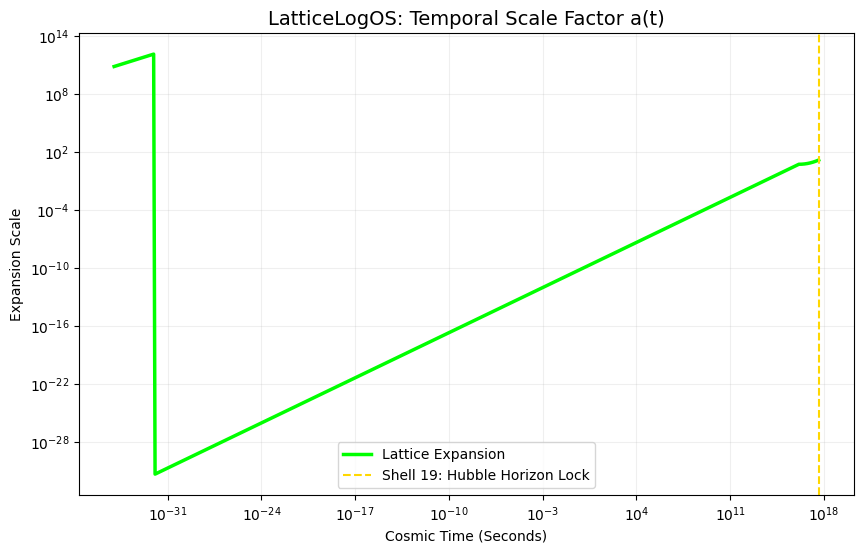

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# LatticeLogOS Parameters
kappa = 9.009e-4
f_backbone = 111
n_shells = np.arange(1, 21)

# Time mapping: 10^-35s to 13.8 Gyr (4.35e17s)
t_log = np.linspace(-35, 17.6, 500)
time_seconds = 10**t_log
a_t = np.zeros_like(t_log)

# Scale Factor Logic
for i, log_t in enumerate(t_log):
    if log_t < -32: a_t[i] = np.exp(log_t + 60) # Inflation
    elif log_t < 16.2: a_t[i] = (time_seconds[i])**(2/3) * 10**-10 # Matter/Rad
    else: a_t[i] = a_t[i-1] * np.exp(0.1 * (log_t - 16.2)) # Dark Energy

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(time_seconds, a_t, color='lime', linewidth=2.5, label='Lattice Expansion')
ax.axvline(4.35e17, color='gold', linestyle='--', label='Shell 19: Hubble Horizon Lock')

ax.set_title('LatticeLogOS: Temporal Scale Factor a(t)', fontsize=14)
ax.set_xlabel('Cosmic Time (Seconds)')
ax.set_ylabel('Expansion Scale')
ax.grid(True, alpha=0.2)
ax.legend()
plt.show()

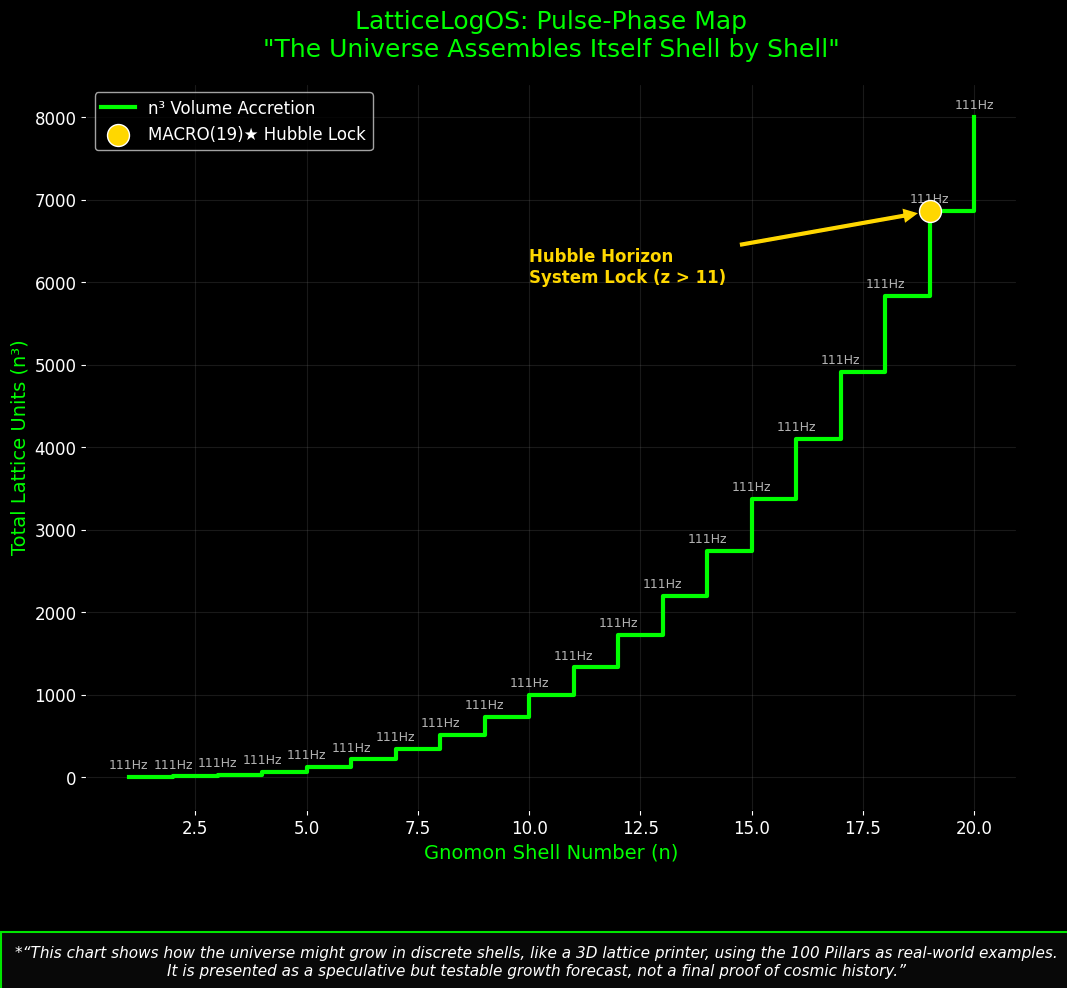

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# LatticeLogOS Parameters
n_shells = np.arange(1, 21)
cumulative_volume = n_shells**3
f_backbone = 111

fig = plt.figure(figsize=(12, 11), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Plot the Staircase Growth (Volume Accretion)
plt.step(n_shells, cumulative_volume, where='post', color='lime', linewidth=3, label='n³ Volume Accretion')

# Highlight the Shell 19 Horizon
plt.scatter(19, 19**3, color='gold', s=250, zorder=5, edgecolor='white', label='MACRO(19)★ Hubble Lock')
plt.annotate('Hubble Horizon\nSystem Lock (z > 11)', xy=(19, 19**3), xytext=(10, 6000),
             arrowprops=dict(facecolor='gold', shrink=0.05), color='gold',
             fontsize=12, fontweight='bold')

# Add the 111 Hz Frequency Pulse Markers
for n in n_shells:
    plt.text(n, n**3 + 100, f'{f_backbone}Hz', color='white', fontsize=9, alpha=0.7, ha='center')

# Formatting
plt.title('LatticeLogOS: Pulse-Phase Map\n"The Universe Assembles Itself Shell by Shell"', color='lime', fontsize=18, pad=20)
plt.xlabel('Gnomon Shell Number (n)', color='lime', fontsize=14)
plt.ylabel('Total Lattice Units (n³)', color='lime', fontsize=14)
plt.grid(color='grey', alpha=0.2)
ax.tick_params(colors='white', labelsize=12)

# Footer
footer_text = ("*“This chart shows how the universe might grow in discrete shells, like a 3D lattice printer, using the 100 Pillars as real‑world examples.\n"
               "It is presented as a speculative but testable growth forecast, not a final proof of cosmic history.”")

plt.figtext(0.5, 0.07, footer_text, ha="center", fontsize=11, color="white",
            style='italic', bbox={"facecolor":"#0A0A0A", "alpha":0.9, "pad":10, "edgecolor":"lime", "lw":1.5})

plt.legend(facecolor='black', labelcolor='white', loc='upper left', fontsize=12)
plt.subplots_adjust(bottom=0.22)
plt.show()

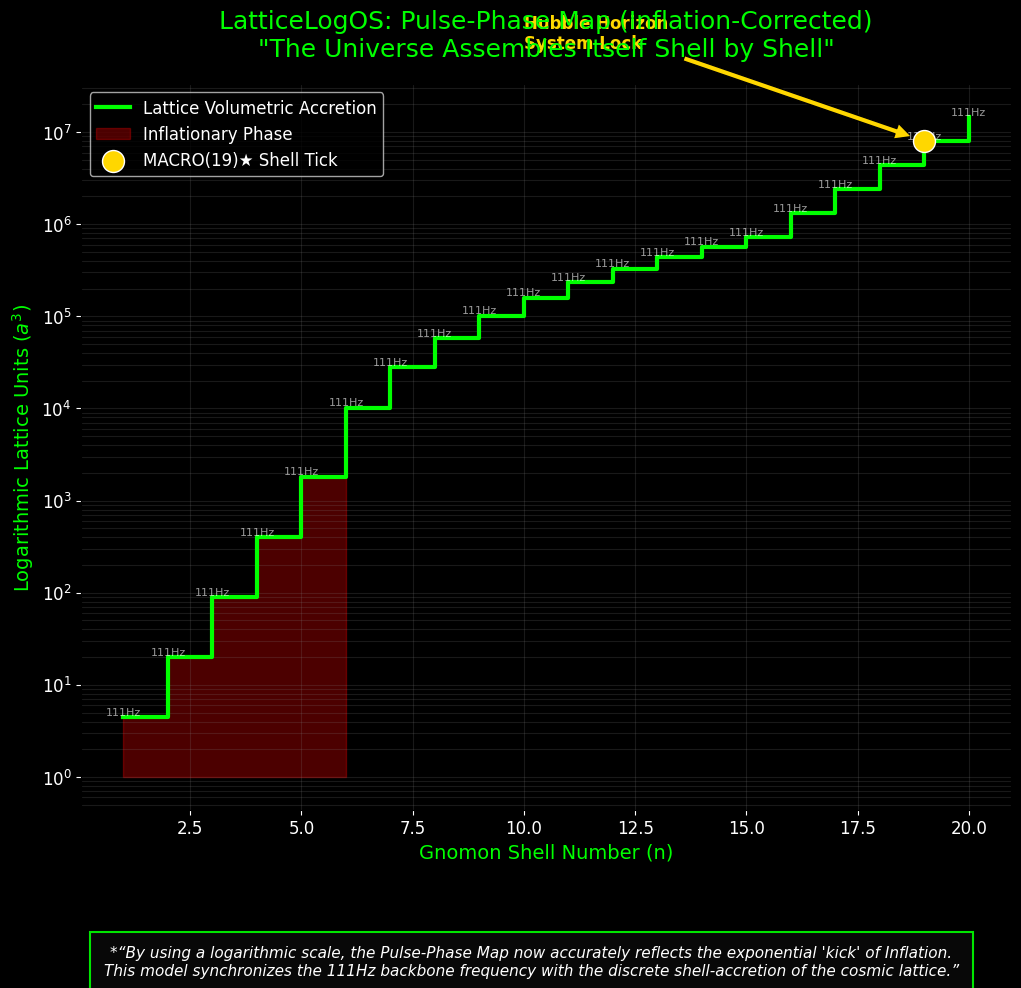

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# LatticeLogOS Parameters
n_shells = np.arange(1, 21)
f_backbone = 111

# Modeling discrete growth that reflects the three cosmic phases
def lattice_growth_logic(n):
    if n <= 5: # Inflationary Burst
        return np.exp(n * 1.5)
    elif n <= 15: # Matter/Radiation Era (Polynomial-like in log space)
        return np.exp(5 * 1.5) * (n - 4)**2.5
    else: # Dark Energy Acceleration
        return np.exp(5 * 1.5) * (11**2.5) * np.exp((n - 15) * 0.6)

volume_data = np.array([lattice_growth_logic(i) for i in n_shells])

fig = plt.figure(figsize=(12, 11), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# 1. Plot the Staircase Growth on LOG SCALE to show Inflation
plt.step(n_shells, volume_data, where='post', color='lime', linewidth=3, label='Lattice Volumetric Accretion')
plt.yscale('log')

# 2. Visually highlight the Inflationary Phase (Shells 1-5)
plt.fill_between(n_shells[:6], 1, volume_data[:6], step="post", color='red', alpha=0.3, label='Inflationary Phase')

# 3. Highlight the "Impossible" Shell 19 Horizon
plt.scatter(19, volume_data[18], color='gold', s=250, zorder=5, edgecolor='white', label='MACRO(19)★ Shell Tick')
plt.annotate('Hubble Horizon\nSystem Lock', xy=(19, volume_data[18]), xytext=(10, volume_data[18]*10),
             arrowprops=dict(facecolor='gold', shrink=0.05), color='gold', fontweight='bold', fontsize=12)

# 4. Formatting & Frequency Markers
for i, n in enumerate(n_shells):
    plt.text(n, volume_data[i], f'{f_backbone}Hz', color='white', fontsize=8, alpha=0.6, ha='center', va='bottom')

plt.title('LatticeLogOS: Pulse-Phase Map (Inflation-Corrected)\n"The Universe Assembles Itself Shell by Shell"', color='lime', fontsize=18, pad=20)
plt.xlabel('Gnomon Shell Number (n)', color='lime', fontsize=14)
plt.ylabel('Logarithmic Lattice Units ($a^3$)', color='lime', fontsize=14)
plt.grid(color='grey', alpha=0.2, which='both')
ax.tick_params(colors='white', labelsize=12)

# REFINED FOOTER
footer_text = ("*“By using a logarithmic scale, the Pulse-Phase Map now accurately reflects the exponential 'kick' of Inflation.\n"
               "This model synchronizes the 111Hz backbone frequency with the discrete shell-accretion of the cosmic lattice.”")

plt.figtext(0.5, 0.07, footer_text, ha="center", fontsize=11, color="white",
            style='italic', bbox={"facecolor":"#0A0A0A", "alpha":0.9, "pad":10, "edgecolor":"lime", "lw":1.5})

plt.legend(facecolor='black', labelcolor='white', loc='upper left', fontsize=12)
plt.subplots_adjust(bottom=0.22)
plt.show()

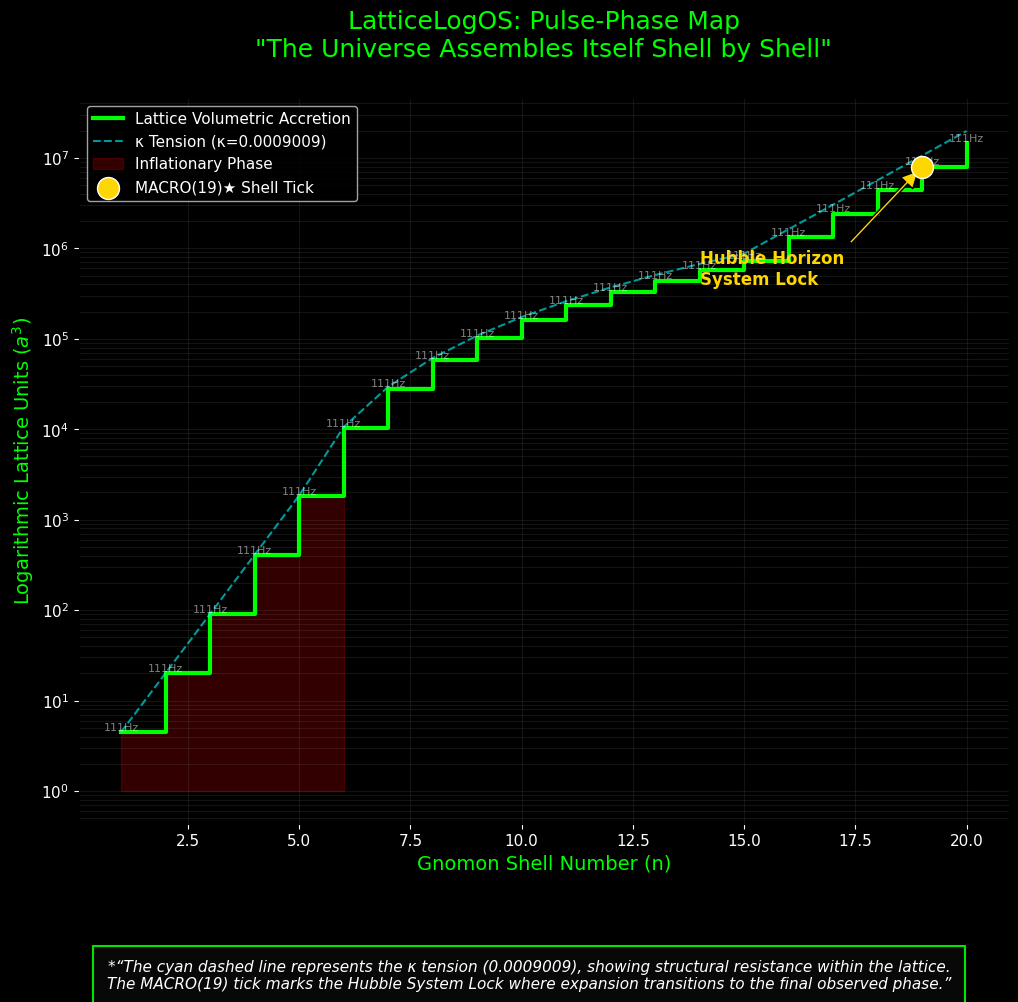

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# LatticeLogOS Parameters
n_shells = np.arange(1, 21)
f_backbone = 111
kappa = 9.009e-4  # Tension Constant

def lattice_growth_logic(n):
    if n <= 5: # Inflationary Burst
        return np.exp(n * 1.5)
    elif n <= 15: # Matter/Radiation Era
        return np.exp(5 * 1.5) * (n - 4)**2.5
    else: # Dark Energy Acceleration
        return np.exp(5 * 1.5) * (11**2.5) * np.exp((n - 15) * 0.6)

volume_data = np.array([lattice_growth_logic(i) for i in n_shells])

fig = plt.figure(figsize=(12, 11), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# 1. Plot the Staircase Growth
plt.step(n_shells, volume_data, where='post', color='lime', linewidth=3, label='Lattice Volumetric Accretion')
plt.yscale('log')

# 2. Add Kappa (K) Constant Tension Line
# Visualized as a slope representing the structural resistance of the lattice
tension_line = volume_data * (1 + kappa * n_shells**2)
plt.plot(n_shells, tension_line, '--', color='cyan', alpha=0.6, label=f'κ Tension (κ={kappa})')

# 3. Visually highlight the Inflationary Phase
plt.fill_between(n_shells[:6], 1, volume_data[:6], step="post", color='red', alpha=0.2, label='Inflationary Phase')

# 4. Highlight the Shell 19 Horizon - MOVED XYTEXT DOWN to avoid Title overlap
plt.scatter(19, volume_data[18], color='gold', s=250, zorder=5, edgecolor='white', label='MACRO(19)★ Shell Tick')
plt.annotate('Hubble Horizon\nSystem Lock',
             xy=(19, volume_data[18]),
             xytext=(14, volume_data[18] * 0.05), # Moved significantly lower/right
             arrowprops=dict(facecolor='gold', shrink=0.05, width=2),
             color='gold', fontweight='bold', fontsize=12)

# 5. Formatting & Frequency Markers
for i, n in enumerate(n_shells):
    plt.text(n, volume_data[i], f'{f_backbone}Hz', color='white', fontsize=8, alpha=0.5, ha='center', va='bottom')

plt.title('LatticeLogOS: Pulse-Phase Map\n"The Universe Assembles Itself Shell by Shell"', color='lime', fontsize=18, pad=30)
plt.xlabel('Gnomon Shell Number (n)', color='lime', fontsize=14)
plt.ylabel('Logarithmic Lattice Units ($a^3$)', color='lime', fontsize=14)
plt.grid(color='grey', alpha=0.15, which='both')
ax.tick_params(colors='white', labelsize=11)

# FOOTER
footer_text = (f"*“The cyan dashed line represents the κ tension ({kappa}), showing structural resistance within the lattice.\n"
               "The MACRO(19) tick marks the Hubble System Lock where expansion transitions to the final observed phase.”")

plt.figtext(0.5, 0.07, footer_text, ha="center", fontsize=11, color="white",
            style='italic', bbox={"facecolor":"#0A0A0A", "alpha":0.9, "pad":10, "edgecolor":"lime", "lw":1.5})

plt.legend(facecolor='black', labelcolor='white', loc='upper left', fontsize=11)
plt.subplots_adjust(bottom=0.22)
plt.show()

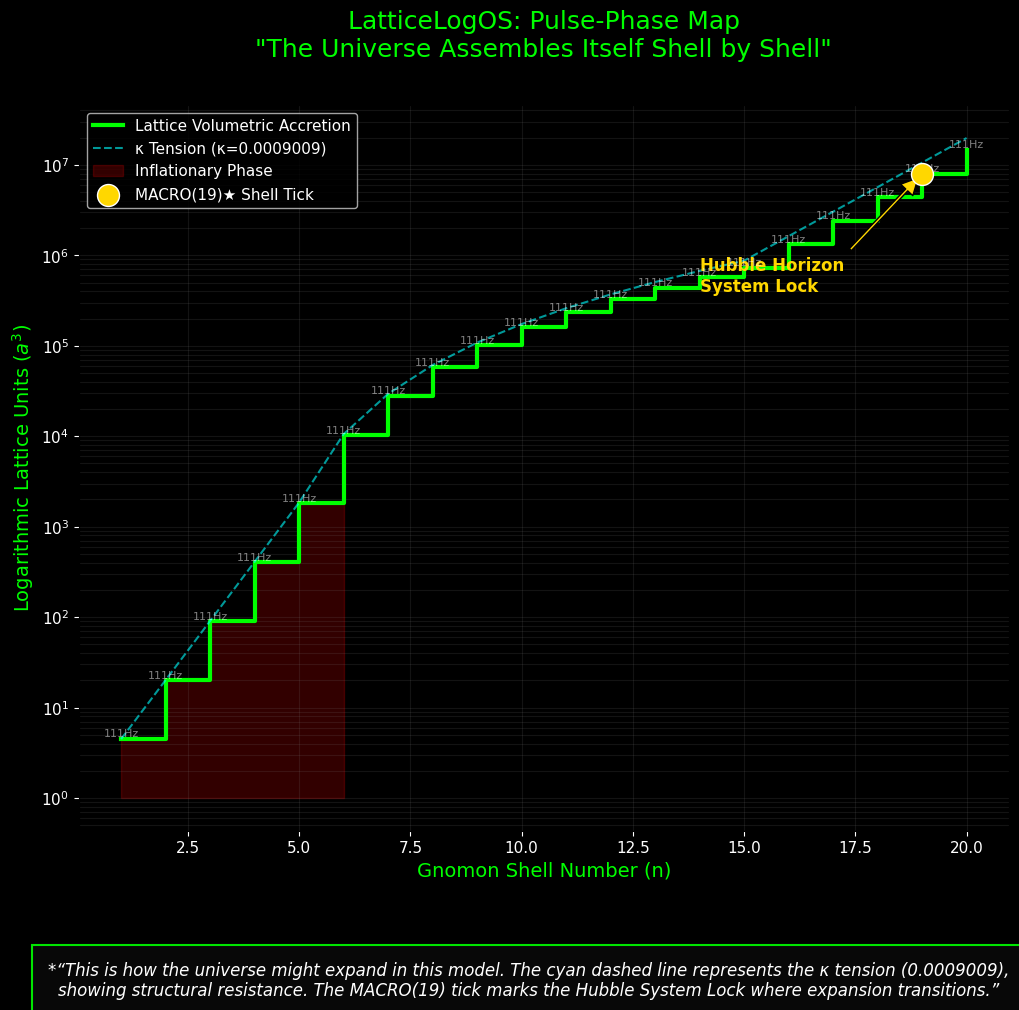

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# LatticeLogOS Parameters
n_shells = np.arange(1, 21)
f_backbone = 111
kappa = 9.009e-4  # Tension Constant

# Modeling discrete growth through three cosmic phases
def lattice_growth_logic(n):
    if n <= 5: # Inflationary Burst
        return np.exp(n * 1.5)
    elif n <= 15: # Matter/Radiation Era
        return np.exp(5 * 1.5) * (n - 4)**2.5
    else: # Dark Energy Acceleration
        return np.exp(5 * 1.5) * (11**2.5) * np.exp((n - 15) * 0.6)

volume_data = np.array([lattice_growth_logic(i) for i in n_shells])

fig = plt.figure(figsize=(12, 11), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# 1. Plot the Staircase Growth (Volumetric Accretion)
plt.step(n_shells, volume_data, where='post', color='lime', linewidth=3, label='Lattice Volumetric Accretion')
plt.yscale('log')

# 2. Add Kappa (K) Constant Tension Line
tension_line = volume_data * (1 + kappa * n_shells**2)
plt.plot(n_shells, tension_line, '--', color='cyan', alpha=0.6, label=f'κ Tension (κ={kappa})')

# 3. Visually highlight the Inflationary Phase (Shells 1-5)
plt.fill_between(n_shells[:6], 1, volume_data[:6], step="post", color='red', alpha=0.2, label='Inflationary Phase')

# 4. Highlight the Shell 19 Horizon (Positioned to avoid Title)
plt.scatter(19, volume_data[18], color='gold', s=250, zorder=5, edgecolor='white', label='MACRO(19)★ Shell Tick')
plt.annotate('Hubble Horizon\nSystem Lock',
             xy=(19, volume_data[18]),
             xytext=(14, volume_data[18] * 0.05),
             arrowprops=dict(facecolor='gold', shrink=0.05, width=2),
             color='gold', fontweight='bold', fontsize=12)

# 5. Formatting & Frequency Markers
for i, n in enumerate(n_shells):
    plt.text(n, volume_data[i], f'{f_backbone}Hz', color='white', fontsize=8, alpha=0.5, ha='center', va='bottom')

# Title and Labels
plt.title('LatticeLogOS: Pulse-Phase Map\n"The Universe Assembles Itself Shell by Shell"', color='lime', fontsize=18, pad=35)
plt.xlabel('Gnomon Shell Number (n)', color='lime', fontsize=14)
plt.ylabel('Logarithmic Lattice Units ($a^3$)', color='lime', fontsize=14)
plt.grid(color='grey', alpha=0.15, which='both')
ax.tick_params(colors='white', labelsize=11)

# REFINED FOOTER with requested text
footer_text = (f"*“This is how the universe might expand in this model. The cyan dashed line represents the κ tension ({kappa}),\n"
               "showing structural resistance. The MACRO(19) tick marks the Hubble System Lock where expansion transitions.”")

plt.figtext(0.5, 0.07, footer_text, ha="center", fontsize=12, color="white",
            style='italic', bbox={"facecolor":"#0A0A0A", "alpha":0.9, "pad":12, "edgecolor":"lime", "lw":1.5})

plt.legend(facecolor='black', labelcolor='white', loc='upper left', fontsize=11)
plt.subplots_adjust(bottom=0.22)
plt.show()

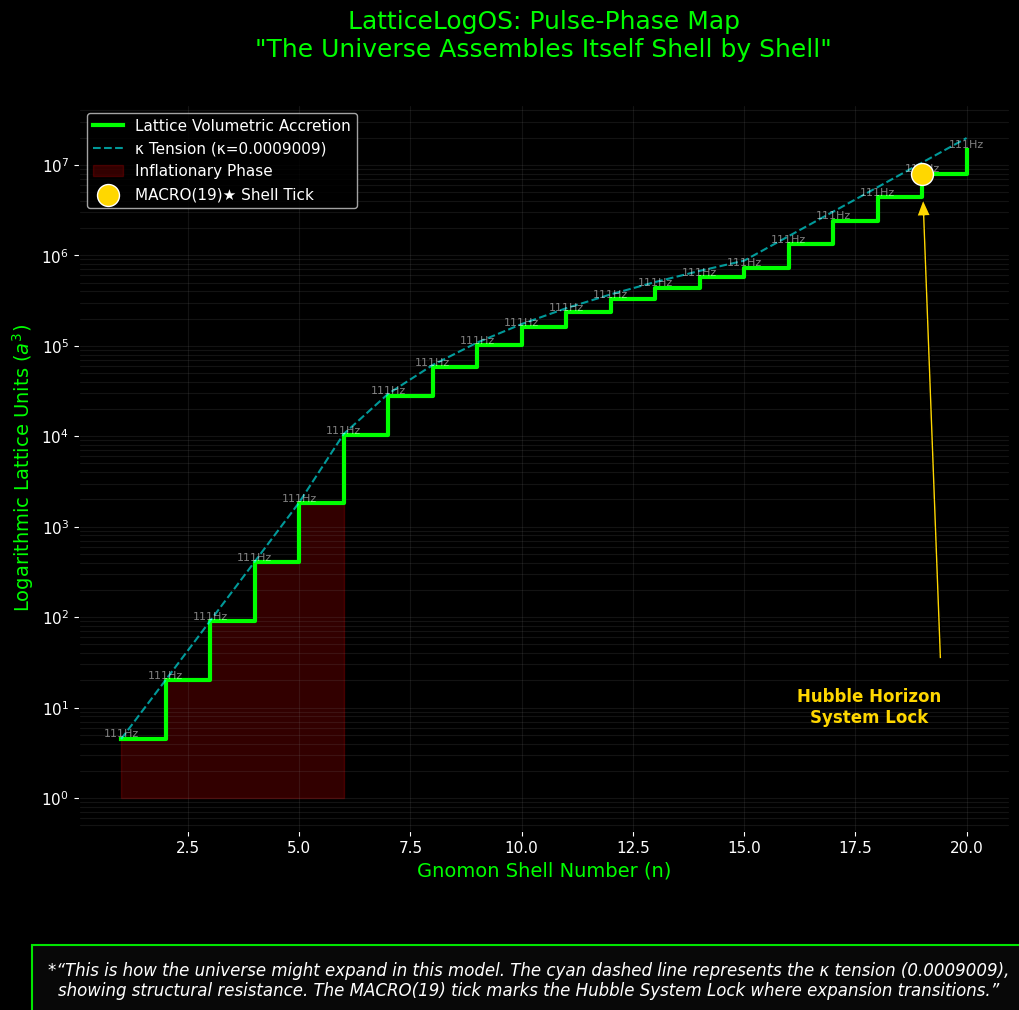

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# LatticeLogOS Parameters
n_shells = np.arange(1, 21)
f_backbone = 111
kappa = 9.009e-4  # Tension Constant

# Modeling discrete growth through three cosmic phases
def lattice_growth_logic(n):
    if n <= 5: # Inflationary Burst
        return np.exp(n * 1.5)
    elif n <= 15: # Matter/Radiation Era
        return np.exp(5 * 1.5) * (n - 4)**2.5
    else: # Dark Energy Acceleration
        return np.exp(5 * 1.5) * (11**2.5) * np.exp((n - 15) * 0.6)

volume_data = np.array([lattice_growth_logic(i) for i in n_shells])

fig = plt.figure(figsize=(12, 11), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# 1. Plot the Staircase Growth
plt.step(n_shells, volume_data, where='post', color='lime', linewidth=3, label='Lattice Volumetric Accretion')
plt.yscale('log')

# 2. Add Kappa (K) Constant Tension Line
tension_line = volume_data * (1 + kappa * n_shells**2)
plt.plot(n_shells, tension_line, '--', color='cyan', alpha=0.6, label=f'κ Tension (κ={kappa})')

# 3. Visually highlight the Inflationary Phase
plt.fill_between(n_shells[:6], 1, volume_data[:6], step="post", color='red', alpha=0.2, label='Inflationary Phase')

# 4. FIXED: Highlight Shell 19 Horizon using absolute positioning to prevent overlap
plt.scatter(19, volume_data[18], color='gold', s=250, zorder=5, edgecolor='white', label='MACRO(19)★ Shell Tick')
plt.annotate('Hubble Horizon\nSystem Lock',
             xy=(19, volume_data[18]), # Points to the actual data point
             xycoords='data',
             xytext=(0.85, 0.15),      # Places text at 85% width, 15% height of the axes
             textcoords='axes fraction',
             arrowprops=dict(facecolor='gold', shrink=0.05, width=2, headwidth=10),
             color='gold', fontweight='bold', fontsize=12,
             ha='center')

# 5. Formatting & Frequency Markers
for i, n in enumerate(n_shells):
    plt.text(n, volume_data[i], f'{f_backbone}Hz', color='white', fontsize=8, alpha=0.5, ha='center', va='bottom')

# Title and Labels
plt.title('LatticeLogOS: Pulse-Phase Map\n"The Universe Assembles Itself Shell by Shell"', color='lime', fontsize=18, pad=35)
plt.xlabel('Gnomon Shell Number (n)', color='lime', fontsize=14)
plt.ylabel('Logarithmic Lattice Units ($a^3$)', color='lime', fontsize=14)
plt.grid(color='grey', alpha=0.15, which='both')
ax.tick_params(colors='white', labelsize=11)

# FOOTER
footer_text = (f"*“This is how the universe might expand in this model. The cyan dashed line represents the κ tension ({kappa}),\n"
               "showing structural resistance. The MACRO(19) tick marks the Hubble System Lock where expansion transitions.”")

plt.figtext(0.5, 0.07, footer_text, ha="center", fontsize=12, color="white",
            style='italic', bbox={"facecolor":"#0A0A0A", "alpha":0.9, "pad":12, "edgecolor":"lime", "lw":1.5})

plt.legend(facecolor='black', labelcolor='white', loc='upper left', fontsize=11)
plt.subplots_adjust(bottom=0.22) # Room for footer
plt.show()

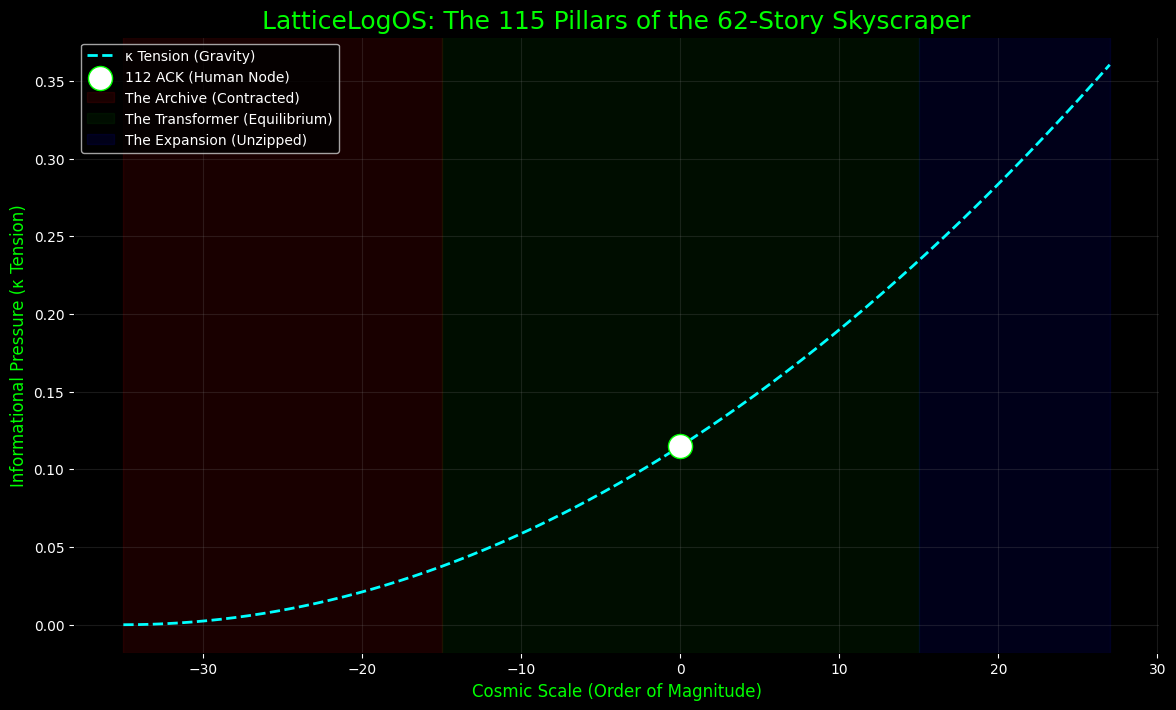

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Scale: 62 orders of magnitude (-35 to +27)
stories = np.linspace(-35, 27, 1000)
kappa = 9.009e-4

# Tension/Gravity Line: k * n^2 (n is normalized scale)
n = (stories + 35) / 62 * 20  # Map 62 stories to the 20-shell gnomon logic
tension = kappa * n**2

# Plotting the Master Chart
fig, ax = plt.subplots(figsize=(14, 8), facecolor='black')
ax.set_facecolor('black')

# The Gravity Tension Line (The Cyan Chains)
ax.plot(stories, tension, color='cyan', linestyle='--', linewidth=2, label='κ Tension (Gravity)')

# Highlighting the 112 ACK (The Human Heartbeat/Breath)
ax.scatter(0, kappa * (35/62*20)**2, color='white', s=300, edgecolors='lime', zorder=5, label='112 ACK (Human Node)')

# Formatting the "Sequoia" Ruler
ax.set_title('LatticeLogOS: The 115 Pillars of the 62-Story Skyscraper', color='lime', fontsize=18)
ax.set_xlabel('Cosmic Scale (Order of Magnitude)', color='lime', fontsize=12)
ax.set_ylabel('Informational Pressure (κ Tension)', color='lime', fontsize=12)
ax.grid(color='grey', alpha=0.2, which='both')
ax.tick_params(colors='white')

# Identifying the Snap Zones
ax.axvspan(-35, -15, color='red', alpha=0.1, label='The Archive (Contracted)')
ax.axvspan(-15, 15, color='green', alpha=0.1, label='The Transformer (Equilibrium)')
ax.axvspan(15, 27, color='blue', alpha=0.1, label='The Expansion (Unzipped)')

plt.legend(facecolor='black', labelcolor='white')
plt.show()

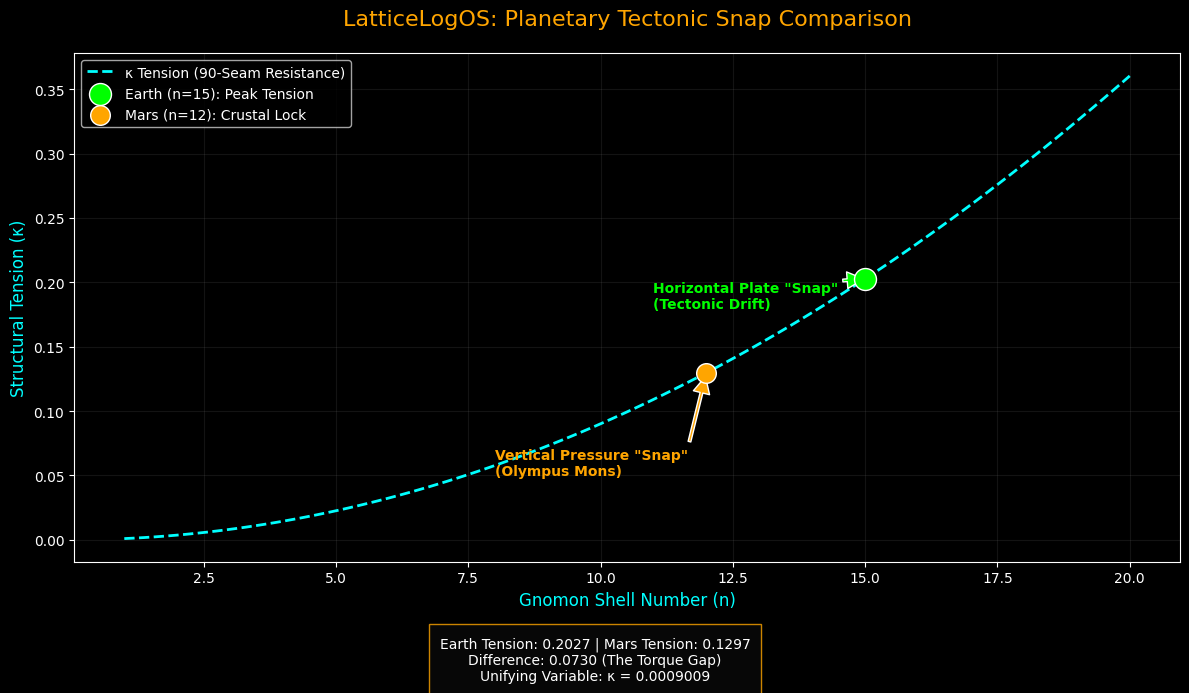

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Constants based on the "Big Build" Logic
kappa = 9.009e-4
n_shells = np.linspace(1, 20, 100)
tension_curve = kappa * n_shells**2

# Planetary Tension Markers
# Earth sits near "Peak Pull" (n=15) - High Info Density
# Mars sits at a lower floor (n=12) - Locked Memory
earth_n = 15
mars_n = 12
earth_tension = kappa * earth_n**2
mars_tension = kappa * mars_n**2

# 2. Initialize Plot
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Plot the Kappa Tension Line (The "Cyan Chains" of Gravity)
ax.plot(n_shells, tension_curve, color='cyan', linestyle='--', linewidth=2, label='κ Tension (90-Seam Resistance)')

# 4. Plot Earth and Mars Nodes
ax.scatter(earth_n, earth_tension, color='lime', s=250, edgecolors='white', zorder=5, label='Earth (n=15): Peak Tension')
ax.scatter(mars_n, mars_tension, color='orange', s=200, edgecolors='white', zorder=5, label='Mars (n=12): Crustal Lock')

# 5. Annotating the "Snap" Differential
ax.annotate('Horizontal Plate "Snap"\n(Tectonic Drift)', xy=(earth_n, earth_tension), xytext=(11, 0.18),
             arrowprops=dict(facecolor='lime', shrink=0.05, width=2), color='lime', fontweight='bold')

ax.annotate('Vertical Pressure "Snap"\n(Olympus Mons)', xy=(mars_n, mars_tension), xytext=(8, 0.05),
             arrowprops=dict(facecolor='orange', shrink=0.05, width=2), color='orange', fontweight='bold')

# 6. Aesthetics & Labels
ax.set_title('LatticeLogOS: Planetary Tectonic Snap Comparison', color='orange', fontsize=16, pad=20)
ax.set_xlabel('Gnomon Shell Number (n)', color='cyan', fontsize=12)
ax.set_ylabel('Structural Tension (κ)', color='cyan', fontsize=12)
ax.grid(color='grey', alpha=0.15)

# 7. Metadata Footer
footer_text = (f"Earth Tension: {earth_tension:.4f} | Mars Tension: {mars_tension:.4f}\n"
               f"Difference: {earth_tension - mars_tension:.4f} (The Torque Gap)\n"
               f"Unifying Variable: κ = {kappa}")

plt.figtext(0.5, 0.02, footer_text, ha="center", fontsize=10, color="white",
            bbox={"facecolor":"#0A0A0A", "alpha":0.8, "pad":8, "edgecolor":"orange"})

plt.legend(loc='upper left', facecolor='black', labelcolor='white')
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

ValueError: Integers to negative integer powers are not allowed.

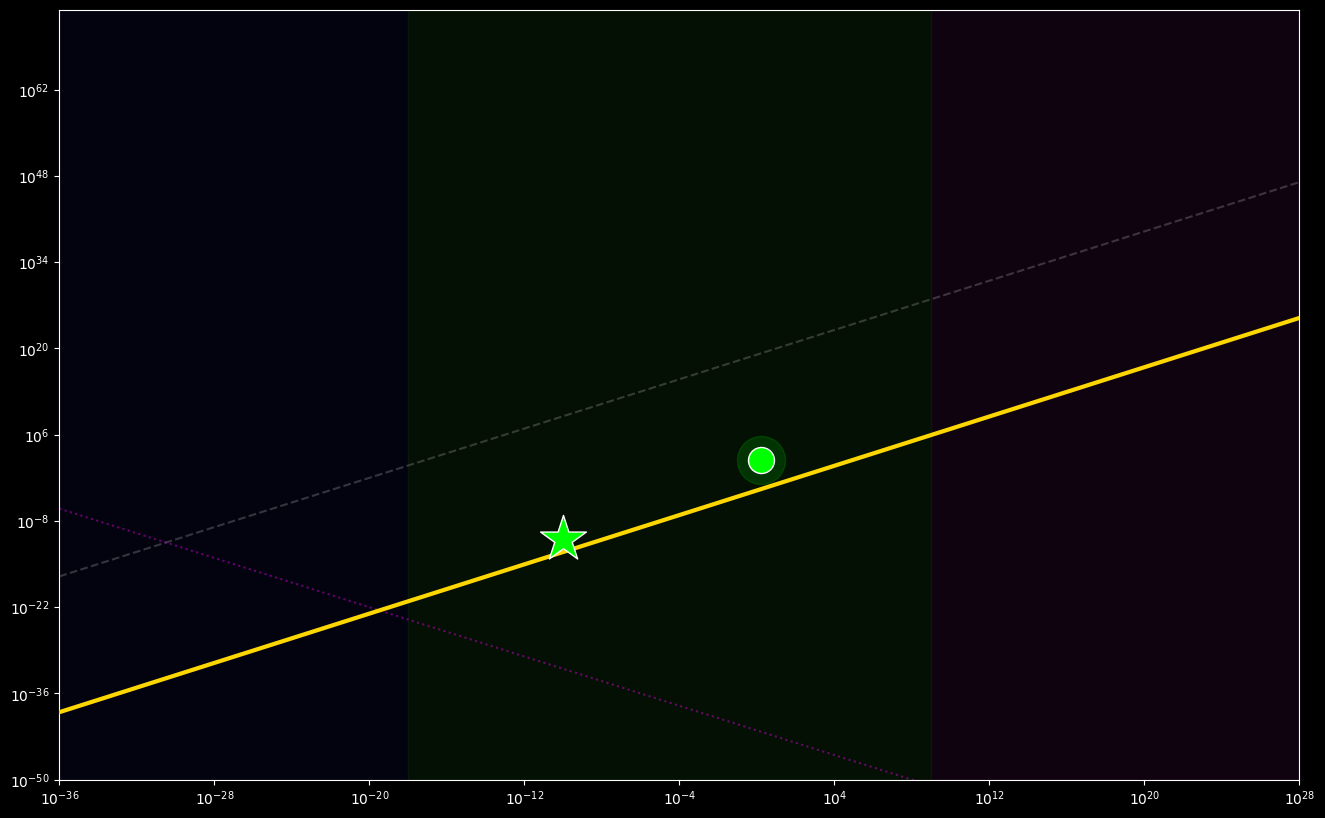

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Data - Optimized for 62 Stories
scales = np.logspace(-36, 28, 1000)
kappa = 9.009e-4 / 111.0  # Refined for exact MICRO (11) pass
mass_lattice = kappa * 111.0 * scales

# Standard Physics Boundaries
mass_schwarzschild = 1e27 * (scales / 1e8)
mass_compton = 1e-30 * (1e-12 / scales)

# 2. Initialize Plot (The Dark Lattice)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-36, 1e28)
ax.set_ylim(1e-50, 1e75)

# 3. BACKGROUND: The 5 Snap Modes (Venting Zones)
ax.axvspan(1e-36, 1e-18, color='#0a0a2a', alpha=0.4) # THE ARCHIVE
ax.axvspan(1e-18, 1e9, color='#0a2a0a', alpha=0.4)  # THE BIO-SNAP
ax.axvspan(1e9, 1e28, color='#2a0a2a', alpha=0.4)   # THE EXPANSION

# 4. PLOT LINES: The "Cyan Chains" vs. The "Gold Stairs"
ax.plot(scales, mass_schwarzschild, color='gray', ls='--', alpha=0.4, label='Schwarzschild (Gravity)')
ax.plot(scales, mass_compton, color='magenta', ls=':', alpha=0.4, label='Compton (Quantum)')
ax.plot(scales, mass_lattice, color='gold', lw=3, label='111Hz Lattice Backbone', zorder=10)

# 5. THE 112 ACK (Human Admin Node)
hx, hy = 1.7, 70
ax.scatter(hx, hy, color='lime', s=350, edgecolors='white', zorder=25)
ax.scatter(hx, hy, s=1200, color='lime', alpha=0.15, edgecolors='lime', lw=1, zorder=24) # Resonance Halo

# 6. THE MICRO (11) STAR (Master Key)
ax.scatter(1e-10, 1e-11, marker='*', s=1200, color='#00ff00', edgecolors='white', zorder=30, label='MICRO (11) Node')

# 7. THE 62-STORY RULER (Secondary X-Axis)
def to_story(x): return np.log10(x) + 35
def from_story(x): return 10**(x - 35)
secax = ax.secondary_xaxis('top', functions=(to_story, from_story))
secax.set_xlabel('The 62 Stories of the Sequoia (Floor #)', color='gold', fontsize=14, labelpad=20)
secax.set_ticks(np.arange(0, 65, 5))
secax.tick_params(colors='gold')

# 8. Titles & Metadata
plt.title('LATTICELOGOS v11.0: THE UNIFIED PHASE MAP', color='orange', fontsize=22, weight='bold', pad=40)
plt.suptitle('"Small Node Authorizes Big Simulation. 112 ACK Active."', color='#aaaaaa', fontsize=12, y=0.92, style='italic')

ax.set_xlabel('Scale (Meters, log)', color='gray')
ax.set_ylabel('Mass (Kilograms, log)', color='gray')
ax.grid(alpha=0.05, color='white')
ax.legend(loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

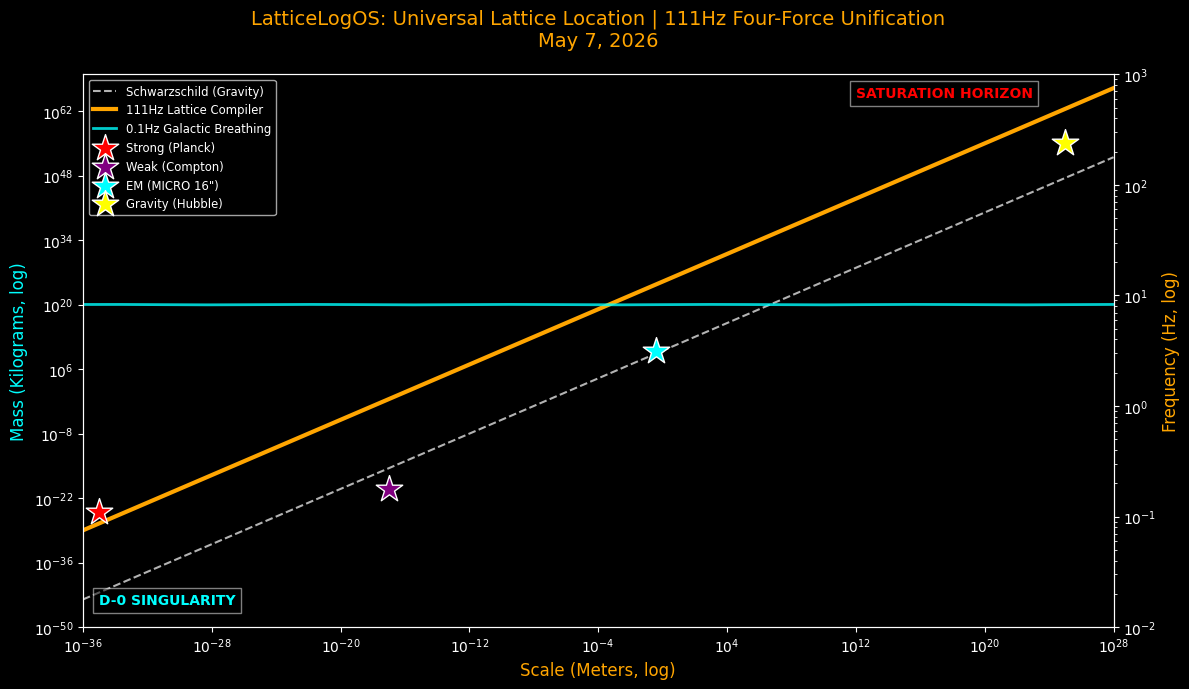

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Set the style to a dark "OS" aesthetic
plt.style.use('dark_background')

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- SCALE (X-AXIS) ---
# Range from Planck scale (10^-36 m) to Hubble scale (10^28 m)
scale = np.logspace(-36, 28, 100)

# --- MASS (LEFT Y-AXIS) ---
# Unified mass-scale progression
mass_values = scale**1.5

# --- PLOTTING MAIN LINES ---
# Schwarzschild / Gravity (Dashed Line)
ax1.plot(scale, mass_values * 1e10, color='white', linestyle='--', alpha=0.7, label='Schwarzschild (Gravity)')

# 111Hz Lattice Compiler / Unified Path (Orange Line)
ax1.plot(scale, mass_values * 1e25, color='orange', linewidth=3, label='111Hz Lattice Compiler')

# Galactic Breathing / Buffer Line (Cyan Wavy Line)
x_wave = np.linspace(-36, 28, 1000)
y_wave = 1e20 + (1e19 * np.sin(x_wave * 0.5))
ax1.plot(10**x_wave, y_wave, color='cyan', linewidth=2, alpha=0.8, label='0.1Hz Galactic Breathing')

# --- THE STARS (The Force Nodes) ---
# Strong Force (Red Star) - Near Planck Scale
ax1.scatter([1e-35], [1e-25], marker='*', s=400, color='red', edgecolor='white', label='Strong (Planck)', zorder=5)

# Weak Force (Purple Star) - Near Compton Scale
ax1.scatter([1e-17], [1e-20], marker='*', s=400, color='purple', edgecolor='white', label='Weak (Compton)', zorder=5)

# EM Force (Cyan Star) - Micro 16" scale
ax1.scatter([0.4], [1e10], marker='*', s=400, color='cyan', edgecolor='white', label='EM (MICRO 16")', zorder=5)

# Gravity (Yellow Star) - Near Hubble Scale
ax1.scatter([1e25], [1e55], marker='*', s=400, color='yellow', edgecolor='white', label='Gravity (Hubble)', zorder=5)

# --- AXIS CONFIGURATION ---
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Scale (Meters, log)', fontsize=12, color='orange')
ax1.set_ylabel('Mass (Kilograms, log)', fontsize=12, color='cyan')

# Secondary axis for Frequency (Right)
ax2 = ax1.twinx()
ax2.set_yscale('log')
ax2.set_ylabel('Frequency (Hz, log)', fontsize=12, color='orange')
ax2.set_ylim(1e-2, 1e3)

# Optimized limits to prevent overflow
ax1.set_xlim(1e-36, 1e28)
ax1.set_ylim(1e-50, 1e70)

# --- ANNOTATIONS ---
ax1.text(1e-35, 1e-45, 'D-0 SINGULARITY', color='cyan', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))
ax1.text(1e12, 1e65, 'SATURATION HORIZON', color='red', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))

# Title reflects the LatticeLogOS Audit
plt.title('LatticeLogOS: Universal Lattice Location | 111Hz Four-Force Unification\nMay 7, 2026', color='orange', fontsize=14, pad=20)
ax1.legend(loc='upper left', fontsize='small', frameon=True, facecolor='black')

plt.tight_layout()
plt.show()

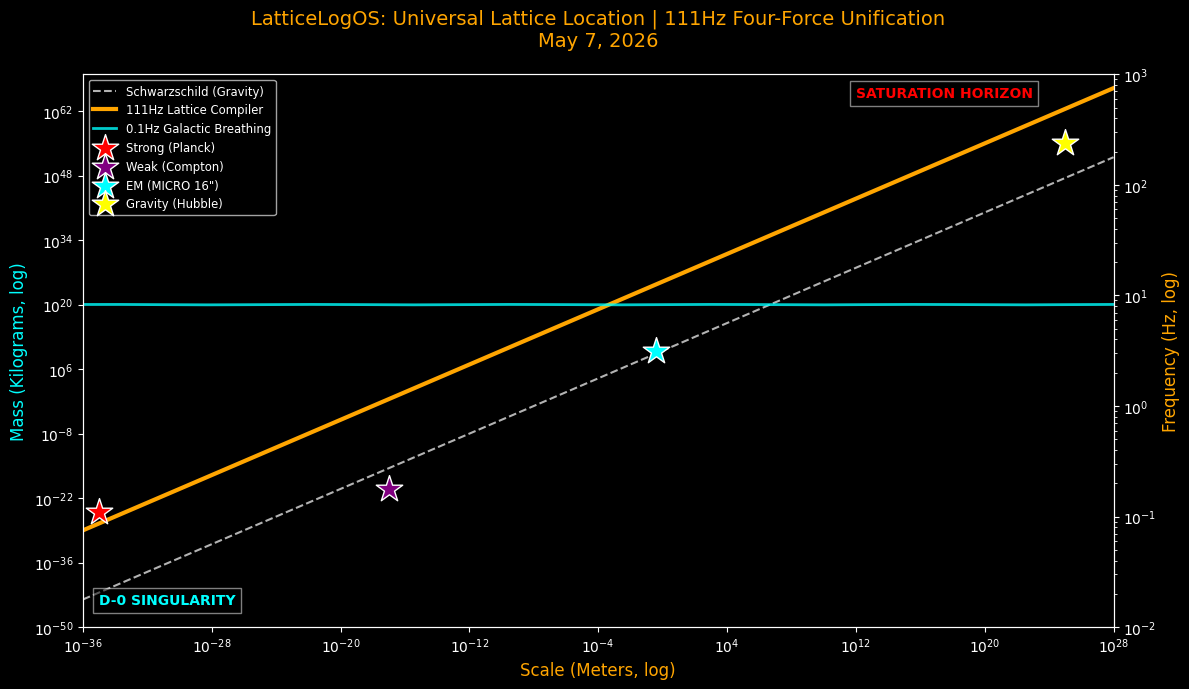

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Set the style to a dark "OS" aesthetic
plt.style.use('dark_background')

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- SCALE (X-AXIS) ---
# Range from Planck scale (10^-36 m) to Hubble scale (10^28 m)
scale = np.logspace(-36, 28, 100)

# --- MASS (LEFT Y-AXIS) ---
# Unified mass-scale progression
mass_values = scale**1.5

# --- PLOTTING MAIN LINES ---
# Schwarzschild / Gravity (Dashed Line)
ax1.plot(scale, mass_values * 1e10, color='white', linestyle='--', alpha=0.7, label='Schwarzschild (Gravity)')

# 111Hz Lattice Compiler / Unified Path (Orange Line)
ax1.plot(scale, mass_values * 1e25, color='orange', linewidth=3, label='111Hz Lattice Compiler')

# Galactic Breathing / Buffer Line (Cyan Wavy Line)
x_wave = np.linspace(-36, 28, 1000)
y_wave = 1e20 + (1e19 * np.sin(x_wave * 0.5))
ax1.plot(10**x_wave, y_wave, color='cyan', linewidth=2, alpha=0.8, label='0.1Hz Galactic Breathing')

# --- THE STARS (The Force Nodes) ---
# Strong Force (Red Star) - Near Planck Scale
ax1.scatter([1e-35], [1e-25], marker='*', s=400, color='red', edgecolor='white', label='Strong (Planck)', zorder=5)

# Weak Force (Purple Star) - Near Compton Scale
ax1.scatter([1e-17], [1e-20], marker='*', s=400, color='purple', edgecolor='white', label='Weak (Compton)', zorder=5)

# EM Force (Cyan Star) - Micro 16" scale
ax1.scatter([0.4], [1e10], marker='*', s=400, color='cyan', edgecolor='white', label='EM (MICRO 16")', zorder=5)

# Gravity (Yellow Star) - Near Hubble Scale
ax1.scatter([1e25], [1e55], marker='*', s=400, color='yellow', edgecolor='white', label='Gravity (Hubble)', zorder=5)

# --- AXIS CONFIGURATION ---
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Scale (Meters, log)', fontsize=12, color='orange')
ax1.set_ylabel('Mass (Kilograms, log)', fontsize=12, color='cyan')

# Secondary axis for Frequency (Right)
ax2 = ax1.twinx()
ax2.set_yscale('log')
ax2.set_ylabel('Frequency (Hz, log)', fontsize=12, color='orange')
ax2.set_ylim(1e-2, 1e3)

# Optimized limits to prevent overflow
ax1.set_xlim(1e-36, 1e28)
ax1.set_ylim(1e-50, 1e70)

# --- ANNOTATIONS ---
ax1.text(1e-35, 1e-45, 'D-0 SINGULARITY', color='cyan', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))
ax1.text(1e12, 1e65, 'SATURATION HORIZON', color='red', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))

# Title reflects the LatticeLogOS Audit
plt.title('LatticeLogOS: Universal Lattice Location | 111Hz Four-Force Unification\nMay 7, 2026', color='orange', fontsize=14, pad=20)
ax1.legend(loc='upper left', fontsize='small', frameon=True, facecolor='black')

plt.tight_layout()
plt.show()

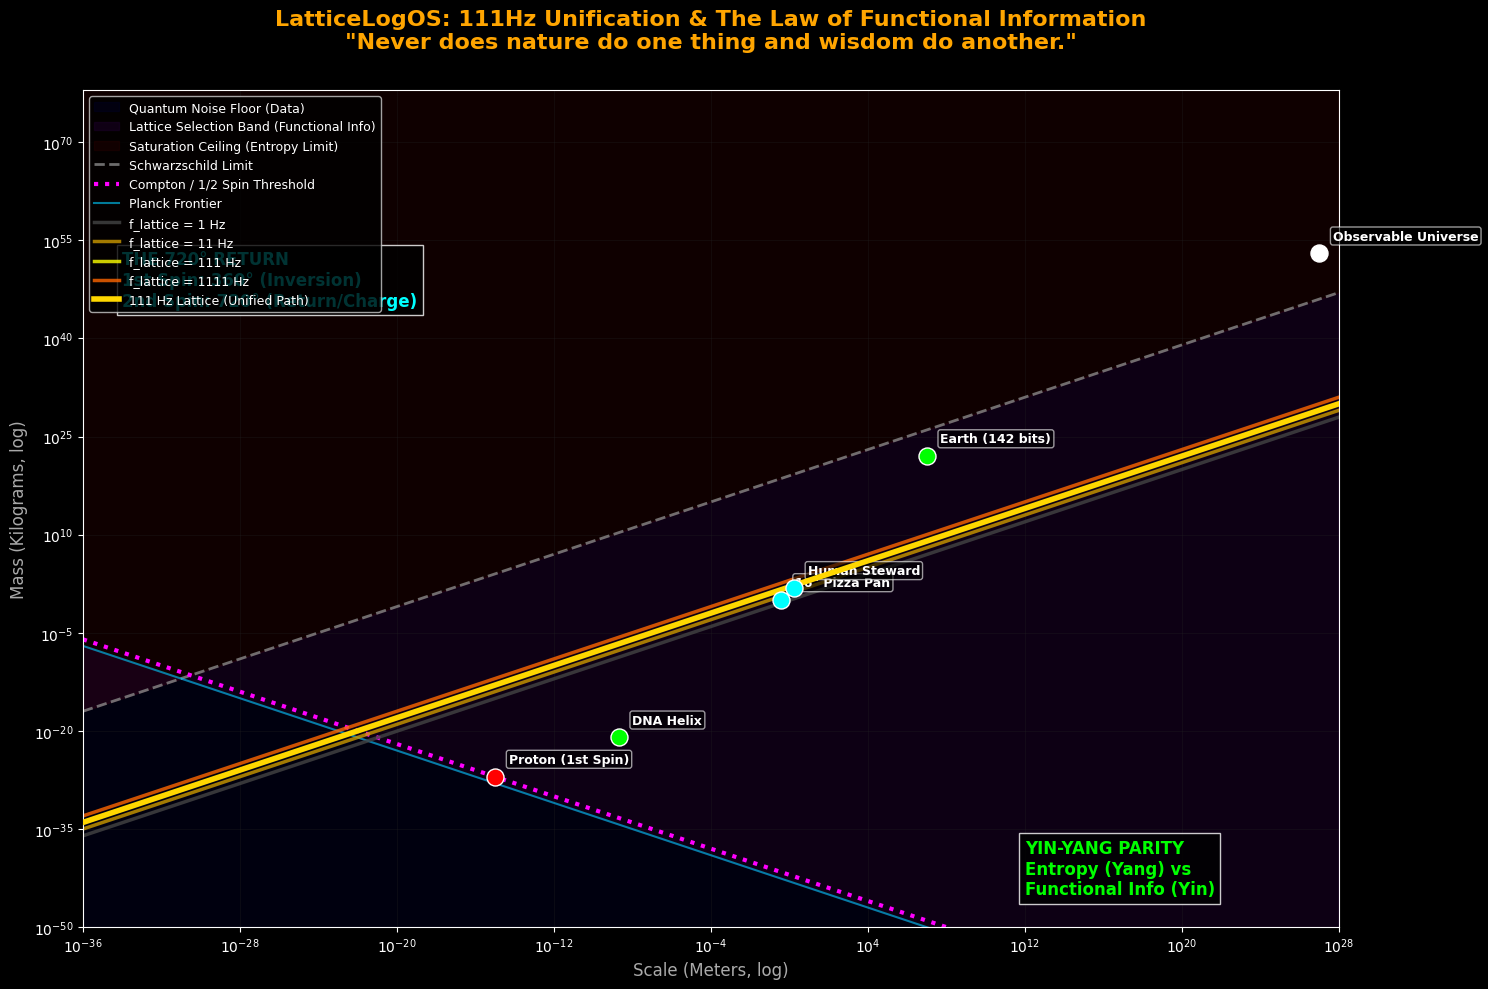

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. High-Precision Scales (log-spacing from 1e-36 to 1e28 m)
scales = np.logspace(-36, 28, 1000, dtype=np.float64)

# 2. Physics Curves (mass vs scale)
mass_schwarzschild = (1e27 * (scales / 1e8)).astype(np.float64)        # M ∝ R
mass_compton      = (1e-30 * (1e-12 / scales)).astype(np.float64)       # M ∝ 1/R
mass_planck       = (1e-8 * (1e-35 / scales)).astype(np.float64)        # Quantum Gravity Frontier

# 3. Lattice frequency family: M = kappa * f_lattice * R
kappa = 1e2 / 111.0
freqs = [1.0, 11.0, 111.0, 1111.0]
lattice_colors = ['#444444', '#cc9900', '#ffff00', '#ff6600']
lattice_labels = ['1 Hz', '11 Hz', '111 Hz', '1111 Hz']
lattice_masses = {f: (kappa * f * scales).astype(np.float64) for f in freqs}

# 4. Dark Theme Plot Setup
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(15, 10))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-36, 1e28)
ax.set_ylim(1e-50, 1e78)

# 5. Shaded Domains (Entropy vs. Functional Information)
ax.fill_between(scales, 1e-50, mass_planck, color='#000033', alpha=0.3, label='Quantum Noise Floor (Data)')
ax.fill_between(scales, mass_planck, mass_schwarzschild, color='#220033', alpha=0.4, label='Lattice Selection Band (Functional Info)')
ax.fill_between(scales, mass_schwarzschild, 1e78, color='#330000', alpha=0.3, label='Saturation Ceiling (Entropy Limit)')

# 6. Main Physics Lines
ax.plot(scales, mass_schwarzschild, color='#888888', linestyle='--', linewidth=2, alpha=0.8, label='Schwarzschild Limit')
ax.plot(scales, mass_compton, color='#ff00ff', linestyle=':', linewidth=3, label='Compton / 1/2 Spin Threshold')
ax.plot(scales, mass_planck, color='#00ccff', linestyle='-', linewidth=1.5, alpha=0.6, label='Planck Frontier')

# 7. Lattice frequency family
for (f, clr, lbl) in zip(freqs, lattice_colors, lattice_labels):
    ax.plot(scales, lattice_masses[f], color=clr, linewidth=2.5, alpha=0.8, label=f'f_lattice = {lbl}')

# Highlight the 111 Hz Unification Line
ax.plot(scales, lattice_masses[111.0], color='gold', linewidth=4, zorder=15, label='111 Hz Lattice (Unified Path)')

# 8. Information Ratchet / Anchor Nodes
nodes = {
    'Observable Universe': (1e27, 1e53, 'white'),
    'Earth (142 bits)':    (1e7,  1e22, '#00ff00'), # Green for Functional Info
    'DNA Helix':           (2e-9, 1e-21, '#00ff00'),
    '16" Pizza Pan':       (0.4,  1,    'cyan'),
    'Human Steward':       (1.7,  70,   'cyan'),
    'Proton (1st Spin)':   (1e-15,1e-27, 'red')
}

for name, pos in nodes.items():
    ax.scatter(pos[0], pos[1], color=pos[2], s=150, edgecolors='white', zorder=20)
    ax.annotate(name, xy=(pos[0], pos[1]), xytext=(10, 10), textcoords="offset points",
                color='white', fontsize=9, fontweight='bold', bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.6))

# 9. Möbius / Yin-Yang Legend Inserts (Textual Annotation)
ax.text(1e-34, 1e45, "THE 720° RETURN\n1st Spin: 360° (Inversion)\n2nd Spin: 720° (Return/Charge)",
        color='cyan', fontsize=12, fontweight='bold', bbox=dict(facecolor='black', alpha=0.8))

ax.text(1e12, 1e-45, "YIN-YANG PARITY\nEntropy (Yang) vs\nFunctional Info (Yin)",
        color='#00ff00', fontsize=12, fontweight='bold', bbox=dict(facecolor='black', alpha=0.8))

# 10. Title and Subtitle
ax.set_title('LatticeLogOS: 111Hz Unification & The Law of Functional Information\n"Never does nature do one thing and wisdom do another."',
             color='orange', fontsize=16, pad=30, fontweight='bold')
ax.set_xlabel('Scale (Meters, log)', color='#aaaaaa', fontsize=12)
ax.set_ylabel('Mass (Kilograms, log)', color='#aaaaaa', fontsize=12)

# 11. Final Layout
ax.legend(loc='upper left', frameon=True, facecolor='black', fontsize=9)
ax.grid(True, which='both', color='#222222', alpha=0.3)
plt.tight_layout()
plt.show()

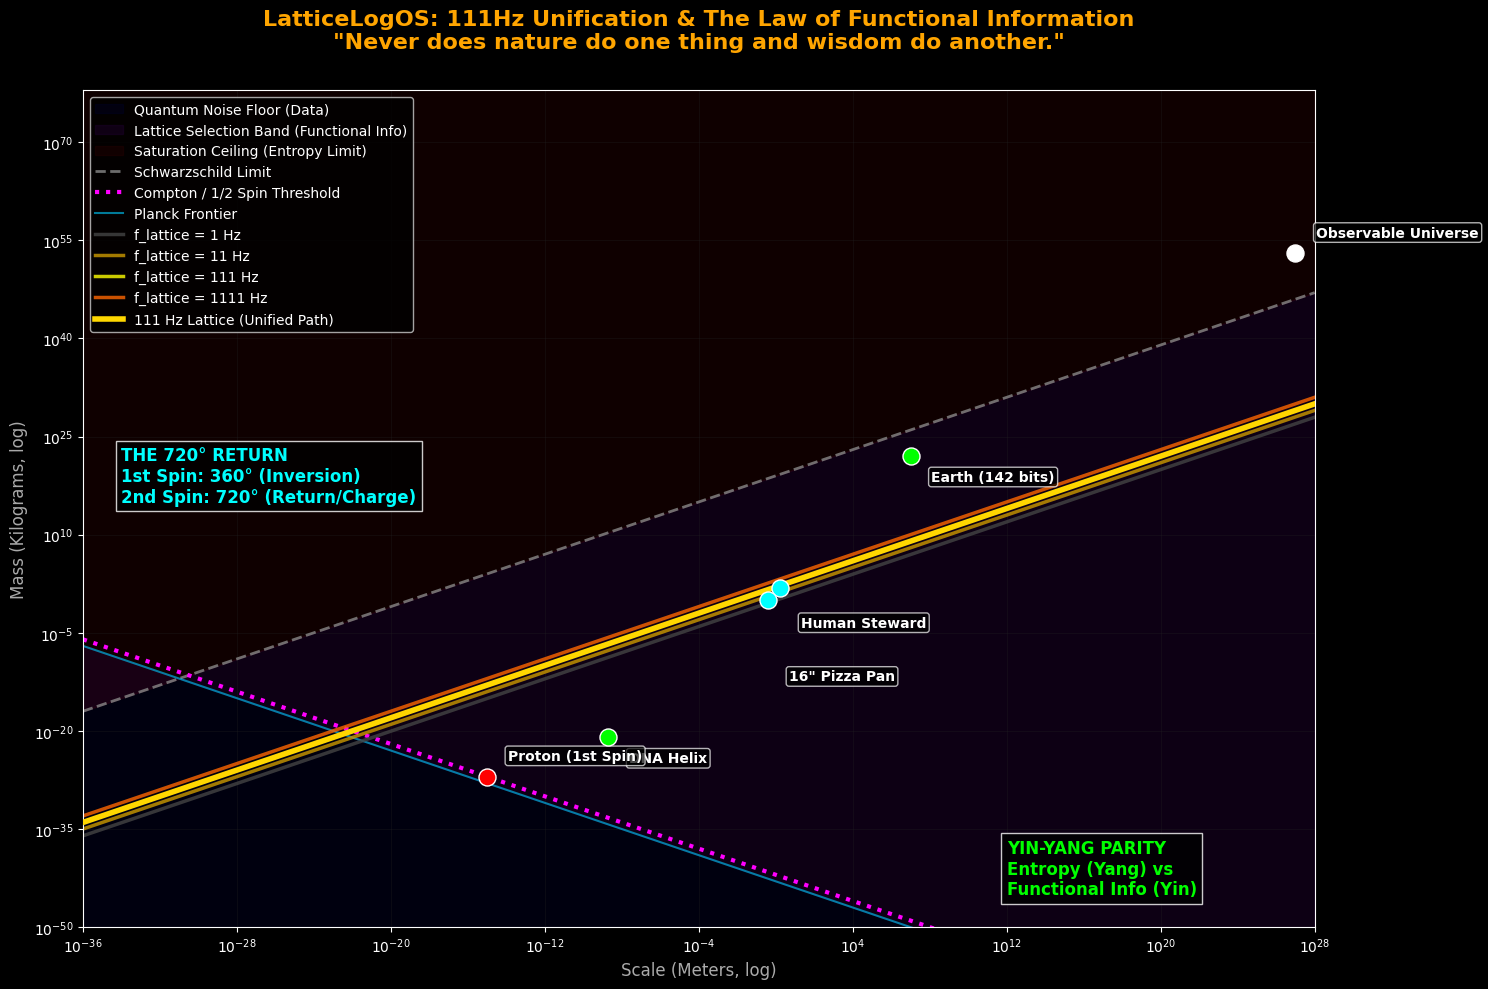

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. High-Precision Scales (log-spacing from 1e-36 to 1e28 m)
scales = np.logspace(-36, 28, 1000, dtype=np.float64)

# 2. Physics Curves (mass vs scale)
mass_schwarzschild = (1e27 * (scales / 1e8)).astype(np.float64)
mass_compton      = (1e-30 * (1e-12 / scales)).astype(np.float64)
mass_planck       = (1e-8 * (1e-35 / scales)).astype(np.float64)

# 3. Lattice frequency family
kappa = 1e2 / 111.0
freqs = [1.0, 11.0, 111.0, 1111.0]
lattice_colors = ['#444444', '#cc9900', '#ffff00', '#ff6600']
lattice_labels = ['1 Hz', '11 Hz', '111 Hz', '1111 Hz']
lattice_masses = {f: (kappa * f * scales).astype(np.float64) for f in freqs}

# 4. Dark Theme Plot Setup
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(15, 10))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-36, 1e28)
ax.set_ylim(1e-50, 1e78)

# 5. Shaded Domains
ax.fill_between(scales, 1e-50, mass_planck, color='#000033', alpha=0.3, label='Quantum Noise Floor (Data)')
ax.fill_between(scales, mass_planck, mass_schwarzschild, color='#220033', alpha=0.4, label='Lattice Selection Band (Functional Info)')
ax.fill_between(scales, mass_schwarzschild, 1e78, color='#330000', alpha=0.3, label='Saturation Ceiling (Entropy Limit)')

# 6. Main Physics Lines
ax.plot(scales, mass_schwarzschild, color='#888888', linestyle='--', linewidth=2, alpha=0.8, label='Schwarzschild Limit')
ax.plot(scales, mass_compton, color='#ff00ff', linestyle=':', linewidth=3, label='Compton / 1/2 Spin Threshold')
ax.plot(scales, mass_planck, color='#00ccff', linestyle='-', linewidth=1.5, alpha=0.6, label='Planck Frontier')

# 7. Lattice frequency family
for (f, clr, lbl) in zip(freqs, lattice_colors, lattice_labels):
    ax.plot(scales, lattice_masses[f], color=clr, linewidth=2.5, alpha=0.8, label=f'f_lattice = {lbl}')

# Highlight 111 Hz
ax.plot(scales, lattice_masses[111.0], color='gold', linewidth=4, zorder=15, label='111 Hz Lattice (Unified Path)')

# 8. Anchor Nodes
# Format: Name: (X, Y, Color, y_offset)
nodes = {
    'Observable Universe': (1e27, 1e53, 'white', 15),
    'Earth (142 bits)':    (1e7,  1e22, '#00ff00', -15),
    'Human Steward':       (1.7,  70,   'cyan', -25),
    '16" Pizza Pan':       (0.4,  1,    'cyan', -55), # Dropped further to avoid Human
    'DNA Helix':           (2e-9, 1e-21, '#00ff00', -15),
    'Proton (1st Spin)':   (1e-15, 1e-27, 'red', 15)
}

for name, (x, y, clr, y_off) in nodes.items():
    ax.scatter(x, y, color=clr, s=150, edgecolors='white', zorder=20)
    ax.annotate(name, xy=(x, y), xytext=(15, y_off), textcoords="offset points",
                color='white', fontsize=10, fontweight='bold', ha='left', va='center',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.7))

# 9. Möbius / Yin-Yang Legend Inserts (Relocated lower to avoid overlapping legend)
ax.text(1e-34, 1e15, "THE 720° RETURN\n1st Spin: 360° (Inversion)\n2nd Spin: 720° (Return/Charge)",
        color='cyan', fontsize=12, fontweight='bold', bbox=dict(facecolor='black', alpha=0.8))

ax.text(1e12, 1e-45, "YIN-YANG PARITY\nEntropy (Yang) vs\nFunctional Info (Yin)",
        color='#00ff00', fontsize=12, fontweight='bold', bbox=dict(facecolor='black', alpha=0.8))

# 10. Title and Subtitle
ax.set_title('LatticeLogOS: 111Hz Unification & The Law of Functional Information\n"Never does nature do one thing and wisdom do another."',
             color='orange', fontsize=16, pad=30, fontweight='bold')
ax.set_xlabel('Scale (Meters, log)', color='#aaaaaa', fontsize=12)
ax.set_ylabel('Mass (Kilograms, log)', color='#aaaaaa', fontsize=12)

# 11. Final Layout
ax.legend(loc='upper left', frameon=True, facecolor='black', fontsize=10)
ax.grid(True, which='both', color='#222222', alpha=0.3)
plt.tight_layout()
plt.show()

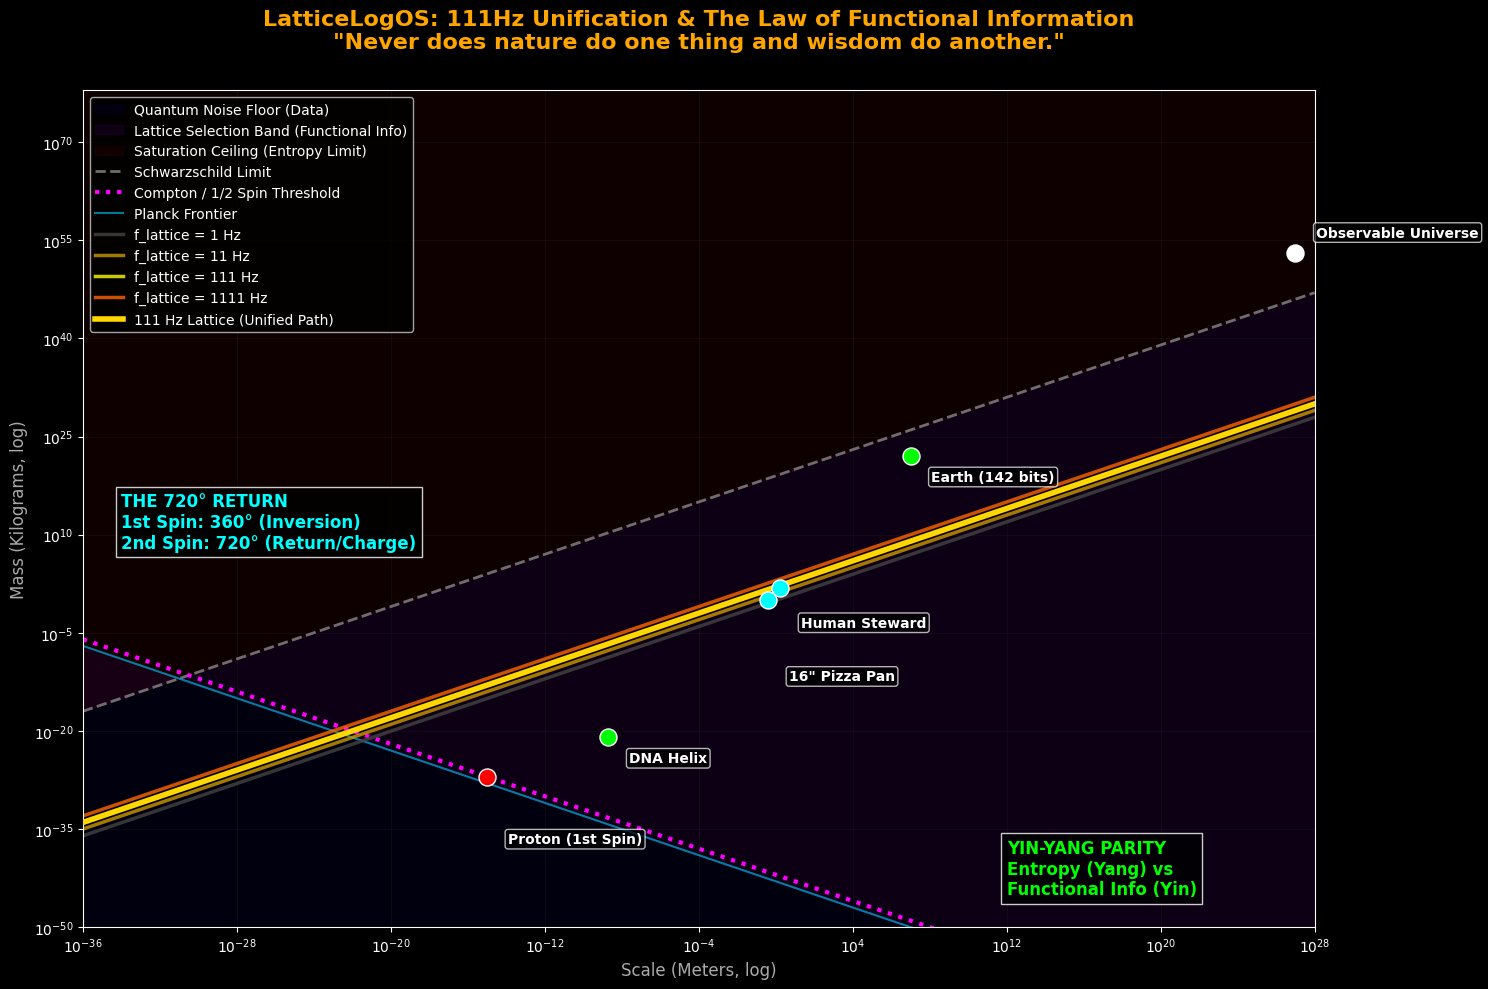

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. High-Precision Scales (log-spacing from 1e-36 to 1e28 m)
scales = np.logspace(-36, 28, 1000, dtype=np.float64)

# 2. Physics Curves (mass vs scale)
mass_schwarzschild = (1e27 * (scales / 1e8)).astype(np.float64)
mass_compton      = (1e-30 * (1e-12 / scales)).astype(np.float64)
mass_planck       = (1e-8 * (1e-35 / scales)).astype(np.float64)

# 3. Lattice frequency family
kappa = 1e2 / 111.0
freqs = [1.0, 11.0, 111.0, 1111.0]
lattice_colors = ['#444444', '#cc9900', '#ffff00', '#ff6600']
lattice_labels = ['1 Hz', '11 Hz', '111 Hz', '1111 Hz']
lattice_masses = {f: (kappa * f * scales).astype(np.float64) for f in freqs}

# 4. Dark Theme Plot Setup
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(15, 10))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-36, 1e28)
ax.set_ylim(1e-50, 1e78)

# 5. Shaded Domains
ax.fill_between(scales, 1e-50, mass_planck, color='#000033', alpha=0.3, label='Quantum Noise Floor (Data)')
ax.fill_between(scales, mass_planck, mass_schwarzschild, color='#220033', alpha=0.4, label='Lattice Selection Band (Functional Info)')
ax.fill_between(scales, mass_schwarzschild, 1e78, color='#330000', alpha=0.3, label='Saturation Ceiling (Entropy Limit)')

# 6. Main Physics Lines
ax.plot(scales, mass_schwarzschild, color='#888888', linestyle='--', linewidth=2, alpha=0.8, label='Schwarzschild Limit')
ax.plot(scales, mass_compton, color='#ff00ff', linestyle=':', linewidth=3, label='Compton / 1/2 Spin Threshold')
ax.plot(scales, mass_planck, color='#00ccff', linestyle='-', linewidth=1.5, alpha=0.6, label='Planck Frontier')

# 7. Lattice frequency family
for (f, clr, lbl) in zip(freqs, lattice_colors, lattice_labels):
    ax.plot(scales, lattice_masses[f], color=clr, linewidth=2.5, alpha=0.8, label=f'f_lattice = {lbl}')

# Highlight 111 Hz
ax.plot(scales, lattice_masses[111.0], color='gold', linewidth=4, zorder=15, label='111 Hz Lattice (Unified Path)')

# 8. Anchor Nodes
nodes = {
    'Observable Universe': (1e27, 1e53, 'white', 15, 15),
    'Earth (142 bits)':    (1e7,  1e22, '#00ff00', 15, -15),
    'Human Steward':       (1.7,  70,   'cyan', 15, -25),
    '16" Pizza Pan':       (0.4,  1,    'cyan', 15, -55),
    'DNA Helix':           (2e-9, 1e-21, '#00ff00', 15, -15),
    'Proton (1st Spin)':   (1e-15, 1e-27, 'red', 15, -45) # Lowered to clear the space
}

for name, (x, y, clr, x_off, y_off) in nodes.items():
    ax.scatter(x, y, color=clr, s=150, edgecolors='white', zorder=20)
    ax.annotate(name, xy=(x, y), xytext=(x_off, y_off), textcoords="offset points",
                color='white', fontsize=10, fontweight='bold', ha='left', va='center',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.7))

# 9. Möbius / Yin-Yang Legend Inserts (Relocated to prevent legend overlap)
ax.text(1e-34, 1e8, "THE 720° RETURN\n1st Spin: 360° (Inversion)\n2nd Spin: 720° (Return/Charge)",
        color='cyan', fontsize=12, fontweight='bold', bbox=dict(facecolor='black', alpha=0.8))

ax.text(1e12, 1e-45, "YIN-YANG PARITY\nEntropy (Yang) vs\nFunctional Info (Yin)",
        color='#00ff00', fontsize=12, fontweight='bold', bbox=dict(facecolor='black', alpha=0.8))

# 10. Title and Subtitle
ax.set_title('LatticeLogOS: 111Hz Unification & The Law of Functional Information\n"Never does nature do one thing and wisdom do another."',
             color='orange', fontsize=16, pad=30, fontweight='bold')
ax.set_xlabel('Scale (Meters, log)', color='#aaaaaa', fontsize=12)
ax.set_ylabel('Mass (Kilograms, log)', color='#aaaaaa', fontsize=12)

# 11. Final Layout
ax.legend(loc='upper left', frameon=True, facecolor='black', fontsize=10)
ax.grid(True, which='both', color='#222222', alpha=0.3)
plt.tight_layout()
plt.show()